In [1]:
import gen
import networkx as nx
import os


In [2]:
repo = gen.Repository()


In [3]:
biobricks = [bg for bg in repo.get_block_groups() if bg.name.startswith('BBa')]
biobricks[:5]

[BlockGroup(2e292ff7980d0bdc757991bbfda3b53f95ee9eafb682d72a67cf0adbfd7a883b, default, None, BBa_J23119),
 BlockGroup(36fdf6ae6658b31ae82aca48ba0fe30857d0a42b380519563b62e9e9e1d4dcca, default, None, BBa_J23100),
 BlockGroup(9227101b59f7259756bf7be47bf1a84486928f752d8b4519932571938bf7d527, default, None, BBa_J23101),
 BlockGroup(1e806e8e40ff3469e34e7fe9b45ce94f02774cfd29c6961cb7469e3f72f9a017, default, None, BBa_J23102),
 BlockGroup(bce52f1ac8f20364844cd0de954fe58eef0083624ab523ce2ef1344abb2bf515, default, None, BBa_J23103)]

In [4]:
[len(repo.block_group_to_networkx(bg).nodes()) for bg in biobricks]

[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]

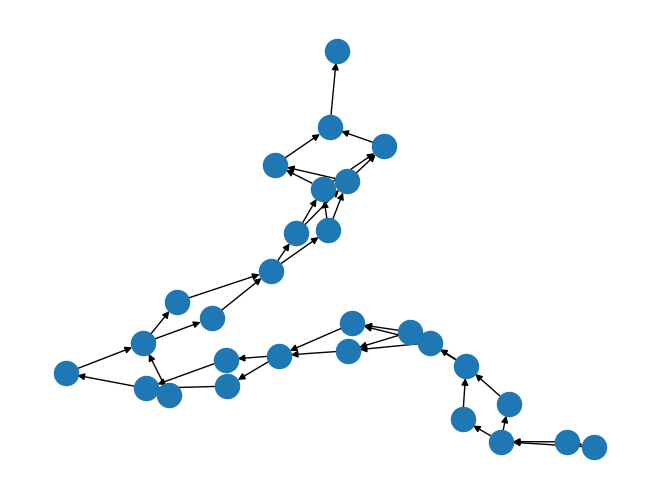

In [5]:
bg = repo.get_block_groups_by_collection('anderson_promoters')[0]
G = repo.block_group_to_networkx(bg)
nx.draw(G)

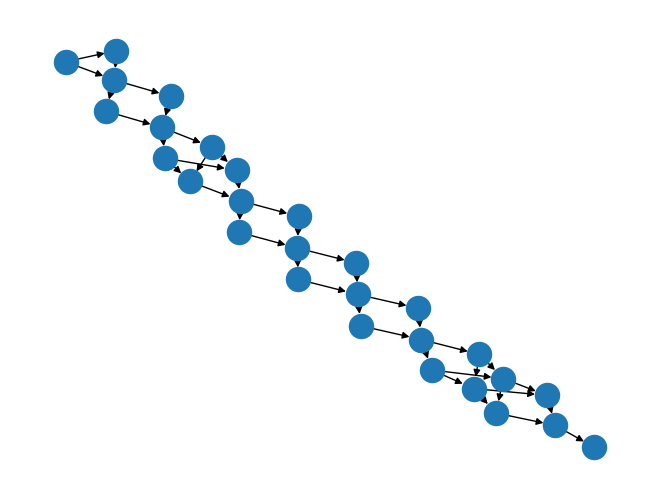

In [6]:
# Let's get a better layout:
pos = nx.nx_agraph.graphviz_layout(G,prog='neato')
nx.draw(G, pos=pos)

In [7]:
sources = [n for n in G.nodes if G.in_degree(n) == 0]
sinks   = [n for n in G.nodes if G.out_degree(n) == 0]

sources, sinks

([NodeKey(84d6adbd5395281933fe41e877d3a7f02a3b1990a65be1901b2c91fc685e083b, 0, 0)],
 [NodeKey(1c7dfc64977b0838af0762d7333dcb64c175b15e65a70099ec38f46bf1a15ea3, 0, 0)])

In [8]:
# How many random walks can I take?
paths = list(nx.all_simple_paths(G, source=sources[0], target=sinks[0]))
len(paths)

1024

In [9]:
# Reconstruct a sequence:
''.join([repo.get_block_sequence(n) for n in paths[0]])

'TTATGGCTAGCTCAGCCCTTGGGATAATGCTAGCTACTAGTGAAAGAGGAGAAATACTAGATGGCTTCCTCCGAAGACGTTATCAAAGAGTTCATGCGTTTCAAAGTTCGTATGGAAGGTTCCGTTAACGGTCACGAGTTCGAAATCGAAGGTGAAGGTGAAGGTCGTCCGTACGAAGGTACCCAGACCGCTAAACTGAAAGTTACCAAAGGTGGTCCGCTGCCGTTCGCTTGGGACATCCTGTCCCCGCAGTTCCAGTACGGTTCCAAAGCTTACGTTAAACACCCGGCTGACATCCCGGACTACCTGAAACTGTCCTTCCCGGAAGGTTTCAAATGGGAACGTGTTATGAACTTCGAAGACGGTGGTGTTGTTACCGTTACCCAGGACTCCTCCCTGCAAGACGGTGAGTTCATCTACAAAGTTAAACTGCGTGGTACCAACTTCCCGTCCGACGGTCCGGTTATGCAGAAAAAAACCATGGGTTGGGAAGCTTCCACCGAACGTATGTACCCGGAAGACGGTGCTCTGAAAGGTGAAATCAAAATGCGTCTGAAACTGAAAGACGGTGGTCACTACGACGCTGAAGTTAAAACCACCTACATGGCTAAAAAACCGGTTCAGCTGCCGGGTGCTTACAAAACCGACATCAAACTGGACATCACCTCCCACAACGAAGACTACACCATCGTTGAACAGTACGAACGTGCTGAAGGTCGTCACTCCACCGGTGCTTAATAACGCTGATAGTGCTAGTGTAGATCGCTACTAGAGCCAGGCATCAAATAAAACGAAAGGCTCAGTCGAAAGACTGGGCCTTTCGTTTTATCTGTTGTTTGTCGGTGAACGCTCTCTACTAGAGTCACACTGGCTCACCTTCGGGTGGGCCTTTCTGCGTTTATATACTAGAAGCGGCCGCTGCAGGCTTCCTCGCTCACTGACTCGCTGCGCTCGGTCGTTCGGCTGCGGCGAGCGGTATCAGCTCACTCAAAGGCGGTA